**Overview**  
This notebook implements the text-only pipeline for the Fake News Detection project.  
It focuses on using headline text alone to detect whether a piece of news is real or fake.

The goal of this notebook is to:
- Explore a textual approach using a pretrained language model  
- Add an LLM reasoning layer to evaluate whether multi-step inference improves decisions  

This pipeline has two levels of prediction:

1. RoBERTa Classifier  
`roberta-base-openai-detector` takes the headline as input, and outputs:
    - `fake` or `real`
    - confidence score (softmax probability)

2. LLM Reasoning Layer  
`gpt-4.1-mini` takes the RoBERTa outputs + headline text, and returns:
    - Decision (Fake / Real)  
    - Short explanation  
    - Nudge (user-facing actionable advice)


**What This Notebook Covers**

- Load the Fakeddit metadata (clean headlines)
- Run RoBERTa classification on sampled headlines
- Pass classifier outputs to GPT-4.1 Mini for reasoning
- Evaluate performance

This is one of the initial pipelines used for early experimentation before building the multimodal agentic system.


# Setup (Dependencies & Imports)

Install required libraries and load all modules used throughout the notebook.

In [28]:
# Install dependencies
!pip install -q transformers torch openai matplotlib seaborn

In [29]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 60 (delta 23), reused 9 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 5.48 MiB | 3.23 MiB/s, done.
Resolving deltas: 100% (23/23), done.


In [30]:
# Imports
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report
from utils.api_key import load_openai_client


In [108]:
# Set OpenAI API
client = load_openai_client()

# Metadata (Dataset Loading & Preparation)

Load the Fakeddit metadata and prepare the headline–label pairs for text-only analysis.

In [33]:
# Load metadata
dataset_url = "https://raw.githubusercontent.com/gizayceylan/FakeNews/main/Datasets/fakeddit_small_2_way.csv"
df = pd.read_csv(dataset_url)

# Drop duplicated rows (if any), and show shape before/after drop
print("Shape original:", df.shape)
df = df.drop_duplicates(keep="first")
print("Shape after removing duplicates:", df.shape)

# Show shape and sample rows
df.head()

Shape original: (50000, 16)
Shape after removing duplicates: (50000, 16)


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,mynameisdom,louisiana town evacuated after million pounds ...,1.354723e+09,newsfeed.time.com,True,14bs3u,https://external-preview.redd.it/_ozmfuaU9hest...,NaN,7.0,30,nottheonion,Louisiana Town Evacuated after 6 Million Pound...,0.78,1,0,0
1,Cardboard95,christiano ronaldo to meet child who lost both...,1.447980e+09,thesportbible.com,True,3ti8nn,https://external-preview.redd.it/lr07F7LhboTVx...,NaN,4.0,33,upliftingnews,Christiano Ronaldo to meet child who lost both...,0.90,1,0,0
2,lukalucasluka,qizai the only brown panda in the world,1.476728e+09,i.redd.it,True,57ytnj,https://preview.redd.it/jkh0z1iqr2sx.jpg?width...,NaN,33.0,1639,photoshopbattles,"PsBattle: Qizai, the only brown panda in the w...",0.97,1,0,0
3,bfwilley,san francisco suspect accused of hate crime in...,1.504455e+09,sanfrancisco.cbslocal.com,True,6xu1o8,https://external-preview.redd.it/szJi1N4Ud4ABH...,NaN,0.0,10,usanews,San Francisco Suspect Accused Of Hate Crime In...,1.00,1,0,0
4,freethinker78,state doctors wife mishandled vaccines caused ...,1.563820e+09,wkyt.com,True,cgguvv,https://external-preview.redd.it/JRFIUMuql9pOJ...,NaN,0.0,22,usnews,"State: Doctor's wife mishandled vaccines, caus...",0.85,1,0,0


In [34]:
# Keep only rows that have image URLs (for consistency with other pipelines)
df = df[df["image_url"].notna()].reset_index(drop=True)
print("Shape after removing rows without image_url:", df.shape)

# Check class balance
label_counts = df['2_way_label'].value_counts().sort_index()
label_percent = df['2_way_label'].value_counts(normalize=True).sort_index() * 100

# Combine into one table for display
balance_df = pd.DataFrame({
    'Label': ['Fake (0)', 'Real (1)'],
    'Count': label_counts.values,
    'Percentage': label_percent.values.round(2)
})

balance_df

Shape after removing rows without image_url: (49845, 16)


,Label,Count,Percentage
0,Fake (0),24963,50.08
1,Real (1),24882,49.92


In [109]:
# Prepare text-only subset
text_df = df[['clean_title', '2_way_label']].dropna().copy()
text_df = text_df.rename(columns={'clean_title': 'text', '2_way_label': 'label'})
text_df["label"] = text_df["label"].astype(int)

# Sample N examples for demonstration
samples = text_df.sample(500, random_state=42).reset_index(drop=True)
samples


,text,label
0,this tiny spoiler on this car,1
1,i am going to a hospital in due to notoriety o...,0
2,flamingo bros where are my shoes,0
3,people really did buy poop on black friday,1
4,chips and salsa worth stolen from exeter stora...,1
...,...,...
495,walking on the beach last night and saw this c...,0
496,know your worth reasons to hold out for a woma...,0
497,words most identical twins share an item youd ...,0
498,other discussions,0


# Classifier (RoBERTa Prediction Layer)

Run the pretrained RoBERTa model to obtain binary fake/real predictions with confidence scores.

In [110]:
# Load model + tokenizer
model_name = "roberta-base-openai-detector"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()


Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [111]:
# Classification helper
def classify_with_roberta(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=1).squeeze()

    pred = torch.argmax(probs).item()
    label = "fake" if pred == 0 else "real"
    confidence = float(probs[pred].item())
    return label, confidence


In [112]:
# Get classifier results
samples[["clf_prediction", "clf_confidence"]] = samples["text"].apply(
    lambda t: pd.Series(classify_with_roberta(t))
)

samples[["text", "label", "clf_prediction", "clf_confidence"]]


,text,label,clf_prediction,clf_confidence
0,this tiny spoiler on this car,1,fake,0.839810
1,i am going to a hospital in due to notoriety o...,0,fake,0.968114
2,flamingo bros where are my shoes,0,fake,0.579836
3,people really did buy poop on black friday,1,real,0.889616
4,chips and salsa worth stolen from exeter stora...,1,fake,0.785687
...,...,...,...,...
495,walking on the beach last night and saw this c...,0,real,0.649047
496,know your worth reasons to hold out for a woma...,0,fake,0.867946
497,words most identical twins share an item youd ...,0,fake,0.522509
498,other discussions,0,fake,0.999129


# LLM Reasoning (GPT-4.1-mini Layer)

Use an LLM to interpret the classifier outputs and generate a final decision, explanation, and nudge.

In [113]:
# LLM promt builder
def build_prompt(text, clf_pred, clf_conf):
    return f"""
You are a misinformation detection assistant.

Here is a news headline:
\"{text}\"

A machine learning classifier predicted this text is: {clf_pred}
Confidence score: {clf_conf:.2f}

Please:
1) Decide whether you agree or disagree with the prediction. Choose ONE of: Real / Fake
2) Provide a SHORT explanation (1–2 sentences).
3) Suggest ONE action the user can take.

Respond EXACTLY in this format:
- Decision:
- Explanation:
- Nudge:
""".strip()


In [114]:
# LLM call wrapper
def query_llm(prompt):
    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        temperature=0,
        max_output_tokens=150
    )
    return response.output_text


In [115]:
# Generate prompts and get responses
samples["llm_response"] = samples.apply(
    lambda row: query_llm(
        build_prompt(
            row["text"],
            row["clf_prediction"],
            row["clf_confidence"]
        )
    ),
    axis=1
)

# Check the raw LLM responses
samples[["text", "label", "llm_response"]]

,text,label,llm_response
0,this tiny spoiler on this car,1,- Decision: Fake \n- Explanation: The headlin...
1,i am going to a hospital in due to notoriety o...,0,- Decision: Fake \n- Explanation: The headlin...
2,flamingo bros where are my shoes,0,- Decision: Fake \n- Explanation: The headlin...
3,people really did buy poop on black friday,1,- Decision: Real \n- Explanation: It is plaus...
4,chips and salsa worth stolen from exeter stora...,1,- Decision: Real \n- Explanation: While the h...
...,...,...,...
495,walking on the beach last night and saw this c...,0,- Decision: Real \n- Explanation: The headlin...
496,know your worth reasons to hold out for a woma...,0,- Decision: Fake \n- Explanation: The headlin...
497,words most identical twins share an item youd ...,0,- Decision: Fake \n- Explanation: The headlin...
498,other discussions,0,- Decision: Fake \n- Explanation: The headlin...


In [116]:
# LLM response parser
def parse_field(resp, key):
    m = re.search(rf"-\s*{key}\s*:\s*(.*)", resp, flags=re.IGNORECASE)
    return m.group(1).strip() if m else ""

samples["llm_decision"]    = samples["llm_response"].map(lambda r: parse_field(r, "Decision"))
samples["llm_explanation"] = samples["llm_response"].map(lambda r: parse_field(r, "Explanation"))
samples["llm_nudge"]       = samples["llm_response"].map(lambda r: parse_field(r, "Nudge"))


In [117]:
# Display the final table with parsed llm response
samples[[
    "text",
    "label",
    "clf_prediction",
    "clf_confidence",
    "llm_decision",
    "llm_explanation",
    "llm_nudge"
]]


,text,label,clf_prediction,clf_confidence,llm_decision,llm_explanation,llm_nudge
0,this tiny spoiler on this car,1,fake,0.839810,Fake,"The headline is vague and lacks context, makin...",Verify the source and look for additional info...
1,i am going to a hospital in due to notoriety o...,0,fake,0.968114,Fake,The headline is incoherent and contains gramma...,Verify the source of the headline and look for...
2,flamingo bros where are my shoes,0,fake,0.579836,Fake,The headline is nonsensical and lacks coherent...,Verify the source of the headline and look for...
3,people really did buy poop on black friday,1,real,0.889616,Real,"It is plausible that novelty or gag gifts, inc...",Check the article source and look for credible...
4,chips and salsa worth stolen from exeter stora...,1,fake,0.785687,Real,"While the headline may seem unusual, thefts in...",Verify the story by checking reputable local n...
...,...,...,...,...,...,...,...
495,walking on the beach last night and saw this c...,0,real,0.649047,Real,The headline describes a personal experience i...,Consider verifying the context or source of th...
496,know your worth reasons to hold out for a woma...,0,fake,0.867946,Fake,The headline promotes outdated and culturally ...,Verify the source of the headline and look for...
497,words most identical twins share an item youd ...,0,fake,0.522509,Fake,"The headline is vague, poorly phrased, and use...",Verify the information by checking reputable n...
498,other discussions,0,fake,0.999129,Fake,"The headline ""other discussions"" is vague and ...",Verify the source and look for more detailed a...


# Evaluation (Metrics & Visualizations)

Compute accuracy, confusion matrices, and classification reports for classifier and LLM outputs.

In [118]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # Unclear or invalid

samples["true_label"] = samples["label"].astype(int)
samples["clf_label"] = samples["clf_prediction"].apply(label_to_int)
samples["llm_label"]  = samples["llm_decision"].apply(label_to_int)

# Clean unclear or invalid LLM decisions (if any)
llm_clean = samples.dropna(subset=["llm_label"])


In [119]:
# Accuracies
clf_acc = np.mean(samples["clf_label"] == samples["true_label"])
llm_acc  = np.mean(llm_clean["llm_label"] == llm_clean["true_label"])
llm_cov = len(llm_clean) / len(samples)

print("RoBERTa Accuracy:", round(clf_acc, 3))
print("GPT Accuracy:", round(llm_acc, 3))
print("GPT Coverage:", round(llm_cov, 3))


RoBERTa Accuracy: 0.594
GPT Accuracy: 0.688
GPT Coverage: 1.0


In [120]:
# Confusion matrices
clf_cm = confusion_matrix(samples["true_label"], samples["clf_label"])
llm_cm  = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])

print("RoBERTa Confusion Matrix:\n", clf_cm)
print("\nGPT Confusion Matrix:\n", llm_cm)


RoBERTa Confusion Matrix:
 [[176  73]
 [130 121]]

GPT Confusion Matrix:
 [[211  38]
 [118 133]]


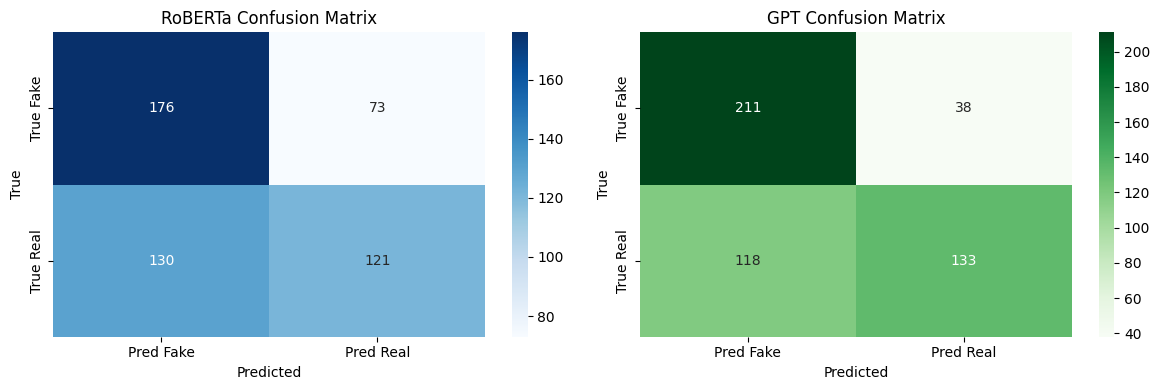

In [121]:
# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(clf_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"], ax=axes[0])
axes[0].set_title("RoBERTa Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(llm_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"], ax=axes[1])
axes[1].set_title("GPT Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()


In [122]:
# Classification reports
print("\n-----------------------------------------------------")
print("RoBERTa Classification Report:")
print("-----------------------------------------------------")
print(classification_report(samples["true_label"], samples["clf_label"], target_names=["Fake", "Real"]))

print("\n-----------------------------------------------------")
print("GPT Classification Report:")
print("-----------------------------------------------------")
print(classification_report(llm_clean["true_label"], llm_clean["llm_label"], target_names=["Fake", "Real"]))



-----------------------------------------------------
RoBERTa Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.58      0.71      0.63       249
        Real       0.62      0.48      0.54       251

    accuracy                           0.59       500
   macro avg       0.60      0.59      0.59       500
weighted avg       0.60      0.59      0.59       500


-----------------------------------------------------
GPT Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.64      0.85      0.73       249
        Real       0.78      0.53      0.63       251

    accuracy                           0.69       500
   macro avg       0.71      0.69      0.68       500
weighted avg       0.71      0.69      0.68       500



**Observations on the Results**

- The RoBERTa classifier achieves 59% accuracy, with higher recall for fake headlines (0.71) but weaker performance on real headlines (0.48). This indicates a tendency to classify ambiguous cases as fake, leading to more false positives for the “fake” class.

- The GPT reasoning layer improves overall performance to 69% accuracy, with a notable gain in detecting fake headlines (recall 0.85). Precision also increases for both classes. However, GPT still shows difficulty with real headlines (recall 0.53), suggesting that the textual modality alone may be limited in capturing real-world nuances.

**Overall,** the LLM reasoning layer provides a substantial improvement over the base classifier, but both models highlight the inherent ambiguity of short headlines and the need for richer multimodal signals (image context or additional metadata) for more reliable decisions.